[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/cdg-ime/blob/main/Mineração.ipynb)

# Ciência de Dados Geoespaciais - Mineração

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Realizar análise exploratória em dados numéricos e categóricos;
2. Realizar análise exploratória em dados geoespaciais;
3. Selecionar modelos mais adequados à solução.

## O Contexto

Com os dados **prospectados** e **pré-processados**, chegamos à etapa de **mineração** — extrair conhecimento e padrões a partir dos dados.

Prospecção $\rightarrow$ Pré-Processamento $\rightarrow$ **Exploração** $\rightarrow$ Modelagem $\rightarrow$ Comunicação 

<img src="media/imgs/mineração.png">



## 1. Realizar análise exploratória em dados numéricos e categóricos

A **Análise Exploratória de Dados (EDA)** precede qualquer modelagem. Seu objetivo é *entender* os dados antes de *explicá-los*. Em ciência de dados geoespaciais, a EDA tem uma dimensão extra: além das estatísticas clássicas, investigamos **onde** os padrões ocorrem.

**Dataset de referência**: [Extração dos dados da plataforma IBGE cidades](https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030) em combinação com malha de referência do IBGE

In [64]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score,
                              classification_report, confusion_matrix)

np.random.seed(42)
sns.set_theme(style='whitegrid')

url_cidades = 'https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030'
api_base = 'https://servicodados.ibge.gov.br/api/v1'
indicadores = {
    96385: 'populacao',
    96386: 'dens_demografica_ibge',
    329756: 'idhm',
    78192: 'ideb_anos_finais_publica',
    143558: 'salario_medio_mensal_sm',
    60030: 'esgotamento_sanitario_pct',
}

def valor_mais_recente(serie):
    """Retorna o valor numérico mais recente de uma série anual da API do IBGE."""
    for ano, valor in sorted(serie.items(), key=lambda item: item[0], reverse=True):
        if valor not in (None, '-', '...'):
            return pd.to_numeric(valor, errors='coerce'), int(ano)
    return np.nan, np.nan

def baixar_indicador(indicador_id, nome_coluna):
    endpoint = f'{api_base}/pesquisas/indicadores/{indicador_id}/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        valor, ano = valor_mais_recente(item['res'])
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            nome_coluna: valor,
            f'{nome_coluna}_ano': ano,
        })
    return pd.DataFrame(registros)

def baixar_populacao_historica():
    endpoint = f'{api_base}/pesquisas/indicadores/96385/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        serie = item['res']
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            'pop_2010': pd.to_numeric(serie.get('2010'), errors='coerce'),
            'pop_2022': pd.to_numeric(serie.get('2022'), errors='coerce'),
        })
    return pd.DataFrame(registros)

def limpar_colunas_ano(gdf):
    """Incorpora colunas *_ano ao nome da variável correspondente e remove o *_ano."""
    renomear = {}
    remover = []
    aliases_analise = {}

    for coluna_ano in sorted(col for col in gdf.columns if col.endswith('_ano')):
        coluna_base = coluna_ano[:-4]
        if coluna_base not in gdf.columns:
            continue

        anos = sorted(gdf[coluna_ano].dropna().astype(int).unique())
        if len(anos) == 1:
            sufixo = str(anos[0])
        elif len(anos) > 1:
            sufixo = str(anos[-1])
            print(f'Aviso: {coluna_ano} possui múltiplos anos {anos}; usando sufixo {sufixo}.')
        else:
            sufixo = 'sem_ano'

        nova_coluna = f'{coluna_base}_{sufixo}'
        renomear[coluna_base] = nova_coluna
        remover.append(coluna_ano)
        aliases_analise[nova_coluna] = coluna_base

    return gdf.rename(columns=renomear).drop(columns=remover), aliases_analise

dados_ibge = None
for indicador_id, nome_coluna in indicadores.items():
    parcial = baixar_indicador(indicador_id, nome_coluna)
    dados_ibge = parcial if dados_ibge is None else dados_ibge.merge(parcial, on='cod_mun6', how='outer')
del dados_ibge['populacao']; del dados_ibge['populacao_ano']


malha_path = 'BR_Municipios_2022.zip'
if not os.path.exists(malha_path):
    malha_url = (
        'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/'
        'malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip'
    )
    malha_path = malha_url

malha = gpd.read_file(malha_path)
malha_rj = malha.query("SIGLA_UF == 'RJ'").copy()
malha_rj['cod_mun6'] = malha_rj['CD_MUN'].astype(str).str[:6]
del malha_rj['CD_MUN']; del malha_rj['SIGLA_UF']

gdf = malha_rj.merge(dados_ibge, on='cod_mun6', how='left')
gdf = gdf.merge(baixar_populacao_historica(), on='cod_mun6', how='left')
gdf = gdf.rename(columns={'NM_MUN': 'municipio', 'AREA_KM2': 'area_km2'})

# Centroide e distância à capital em um CRS métrico adequado ao RJ.
gdf_m = gdf.to_crs('EPSG:31983')
centroides_m = gdf_m.geometry.centroid
capital_geom = centroides_m.loc[gdf['municipio'].eq('Rio de Janeiro')].iloc[0]
gdf['dist_capital_km'] = (centroides_m.distance(capital_geom) / 1000).round(1)
gdf = gdf.to_crs('EPSG:4326')

# Variáveis derivadas a partir dos dados oficiais.
gdf['cresc_pop_pct'] = ((gdf['pop_2022'] / gdf['pop_2010'] - 1) * 100).round(2)
gdf['classe_dev'] = pd.cut(
    gdf['idhm'],
    bins=[0, 0.699, 0.799, 1.0],
    labels=['Médio', 'Alto', 'Muito Alto']
)

# Limpar anos e renomer colunas dos anos
gdf, aliases_analise = limpar_colunas_ano(gdf)

print(f'Fonte IBGE Cidades: {url_cidades}')
print(f'Shape gdf limpo: {gdf.shape}')
gdf.head()

Aviso: ideb_anos_finais_publica_ano possui múltiplos anos [np.int64(2021), np.int64(2023)]; usando sufixo 2023.
Fonte IBGE Cidades: https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030
Shape gdf limpo: (92, 14)


,municipio,area_km2,geometry,cod_mun6,dens_demografica_ibge_2022,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2023,esgotamento_sanitario_pct_2022,pop_2010,pop_2022,dist_capital_km,cresc_pop_pct,classe_dev
0,Angra dos Reis,813.420,"MULTIPOLYGON (((-44.51649 -23.03589, -44.51633...",330010,205.84,0.724,4.4,3.2,69.95,169511,167434,92.7,-1.23,Alto
1,Aperibé,94.542,"POLYGON ((-42.11437 -21.61204, -42.11394 -21.6...",330015,116.71,0.692,5.3,1.8,84.82,10213,11034,195.5,8.04,Médio
2,Araruama,638.276,"POLYGON ((-42.28399 -22.93928, -42.28444 -22.9...",330020,203.16,0.718,4.3,1.6,32.34,112008,129671,120.3,15.77,Alto
3,Areal,110.724,"POLYGON ((-43.09004 -22.23844, -43.09135 -22.2...",330022,106.82,0.684,4.1,2.5,41.54,11423,11828,83.4,3.55,Médio
4,Armação dos Búzios,70.977,"MULTIPOLYGON (((-41.91872 -22.77162, -41.91854...",330023,563.65,0.728,4.0,1.9,30.79,27560,40006,155.0,45.16,Alto


### **1.1 Síntese numérica**

**Estatísticas descritivas**

In [93]:
est = gdf.describe().T
# Extra: relative standard deviation
est['rsd%'] = 100* est['std'] / est['mean']
est.round(2)

,count,mean,std,min,25%,50%,75%,max,rsd%
area_km2,92.0,475.55,488.22,19.39,215.62,373.61,586.25,4032.49,102.66
dens_demografica_ibge_2022,92.0,682.04,1797.64,12.62,51.89,109.48,311.11,12521.64,263.57
idhm_2010,92.0,0.71,0.04,0.61,0.68,0.71,0.73,0.84,5.19
ideb_anos_finais_publica_2023,92.0,4.50,0.55,3.50,4.07,4.40,4.90,5.80,12.32
salario_medio_mensal_sm_2023,92.0,2.12,0.65,1.20,1.80,1.90,2.20,5.70,30.90
esgotamento_sanitario_pct_2022,92.0,67.49,20.33,2.86,56.04,70.59,82.74,98.71,30.12
pop_2010,92.0,173803.58,672081.03,5269.00,17502.25,34878.50,113948.25,6320446.00,386.69
pop_2022,92.0,174512.76,658952.50,5415.00,17476.75,37767.00,132384.00,6211223.00,377.60
dist_capital_km,92.0,123.59,75.49,0.00,64.08,109.10,170.23,291.50,61.09
cresc_pop_pct,92.0,5.09,11.25,-12.87,-0.77,1.84,7.76,54.77,220.88


### **1.2 Síntese gráfica**

<img src="media/imgs/sitese_grafica.png">

### **1.2.1 Histograma das variáveis numéricas**

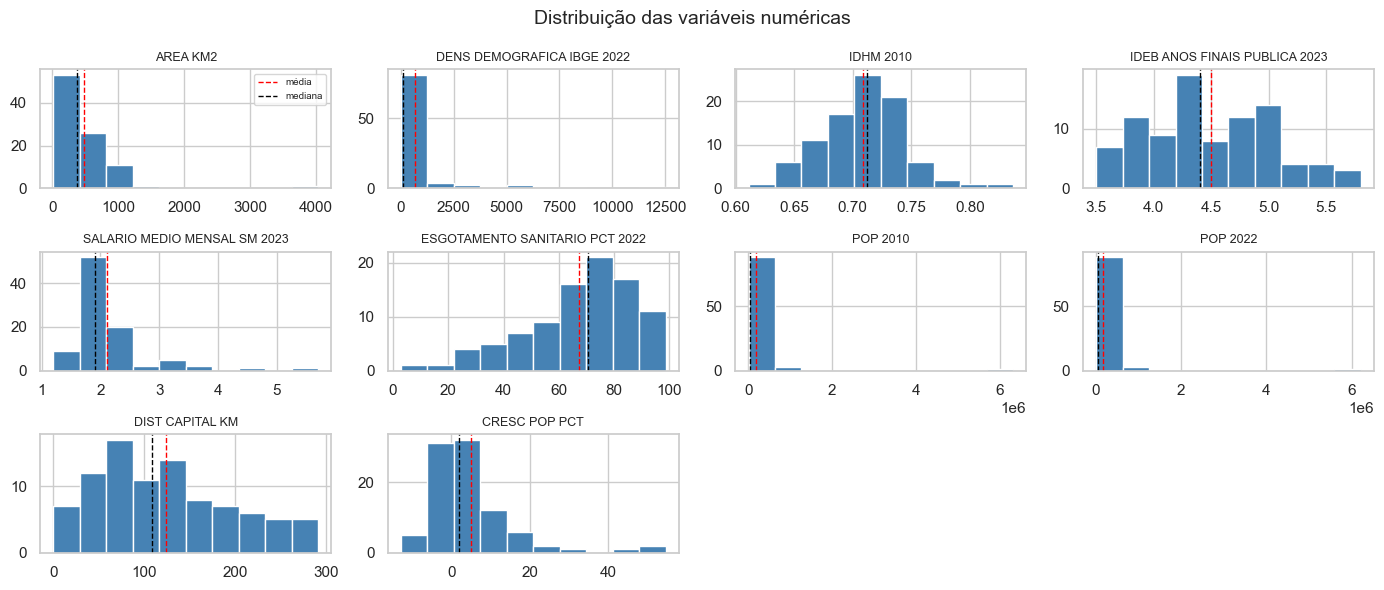

In [127]:
num_cols = gdf.describe().columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(gdf[col].dropna(), bins=10, edgecolor='white', color='steelblue')
    ax.set_title(col.upper().replace("_"," "), fontsize=9)
    ax.axvline(gdf[col].mean(),   color='red',    linestyle='--', linewidth=1, label='média')
    ax.axvline(gdf[col].median(), color='black', linestyle='--',  linewidth=1, label='mediana')

axes[0,0].legend(fontsize=7)
# Turn off the axes
axes[2,2].axis('off'); axes[2,3].axis('off')
plt.suptitle('Distribuição das variáveis numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### **1.2.2 Boxplot das variáveis numéricas**

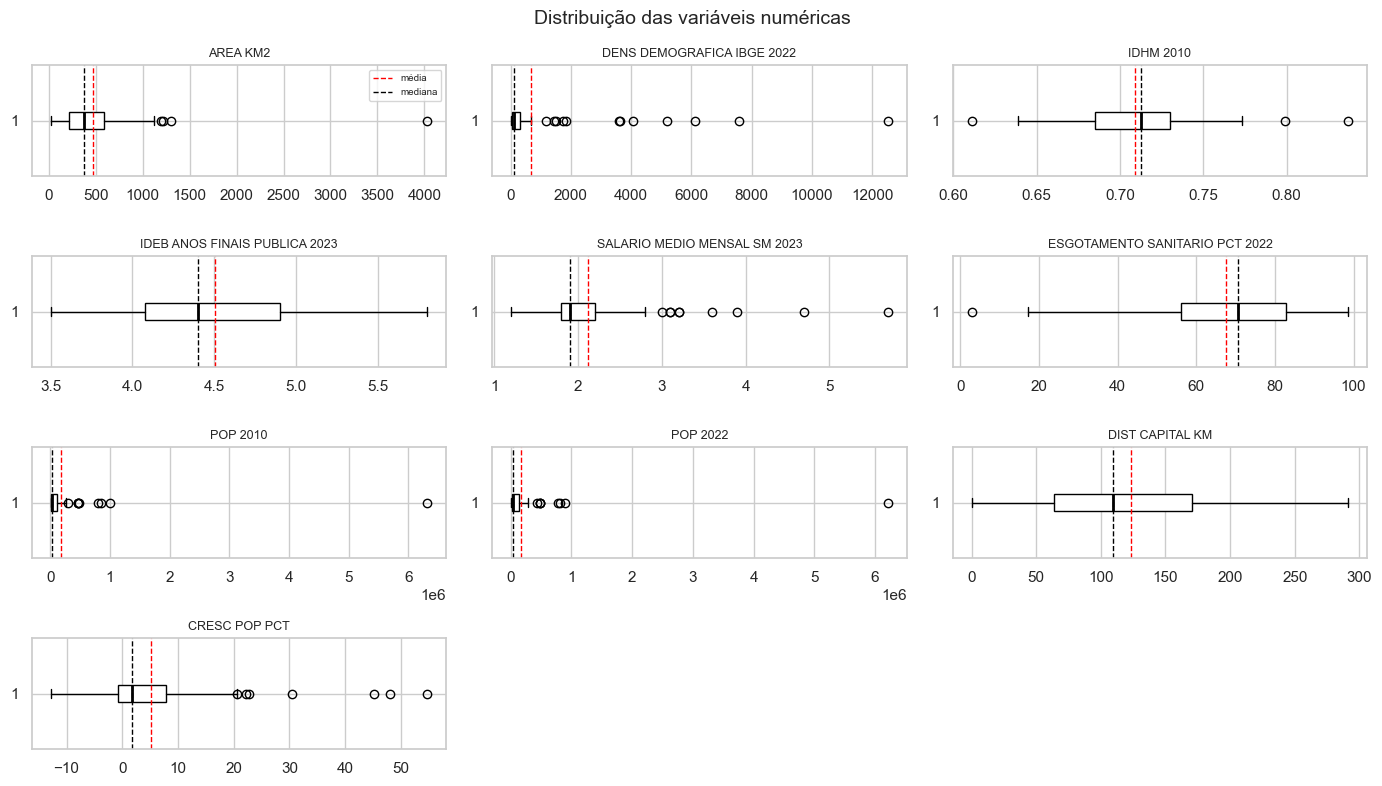

In [129]:
fig, axes = plt.subplots(4, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.boxplot(
        gdf[col],
        vert=False,
        patch_artist=True,
        showfliers=True,
        boxprops=dict(facecolor="white", edgecolor="black"),
        medianprops=dict(color="black", linewidth=2),
    )
    ax.set_title(col.upper().replace("_"," "), fontsize=9)
    ax.axvline(gdf[col].mean(),   color='red',    linestyle='--', linewidth=1, label='média')
    ax.axvline(gdf[col].median(), color='black', linestyle='--',  linewidth=1, label='mediana')
axes[0,0].legend(fontsize=7)
# Turn off the axes
axes[3,2].axis('off'); axes[3,1].axis('off')
plt.suptitle('Distribuição das variáveis numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### **1.2.3 Relação entre duas variáveis numéricas**

O **coeficiente de correlação de Pearson** ($r$) mede a força e a direção da relação linear entre duas variáveis contínuas:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i-\bar{x})^2 \cdot \sum (y_i-\bar{y})^2}} \quad \in [-1, 1]$$

> A correlaçã **não implica causalidade**. Sempre interprete no contexto do domí­nio.

### **1.2.4 Matriz de correlação**

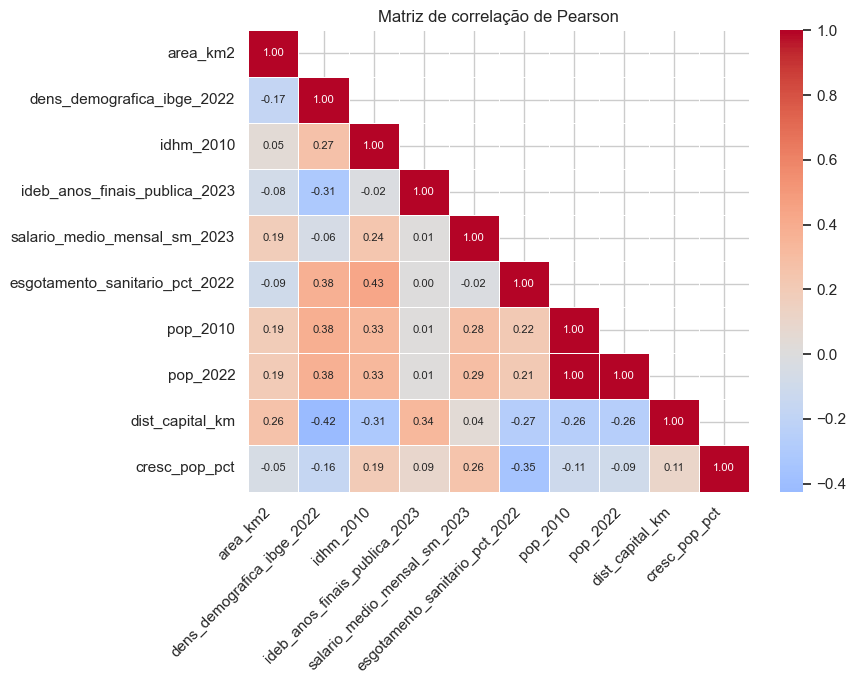

In [ ]:
#  Mapa de calor de correlações
corr = gdf[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(corr.values, 1)  # Apenas triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlação de Pearson', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **1.2.5 Dispersão**

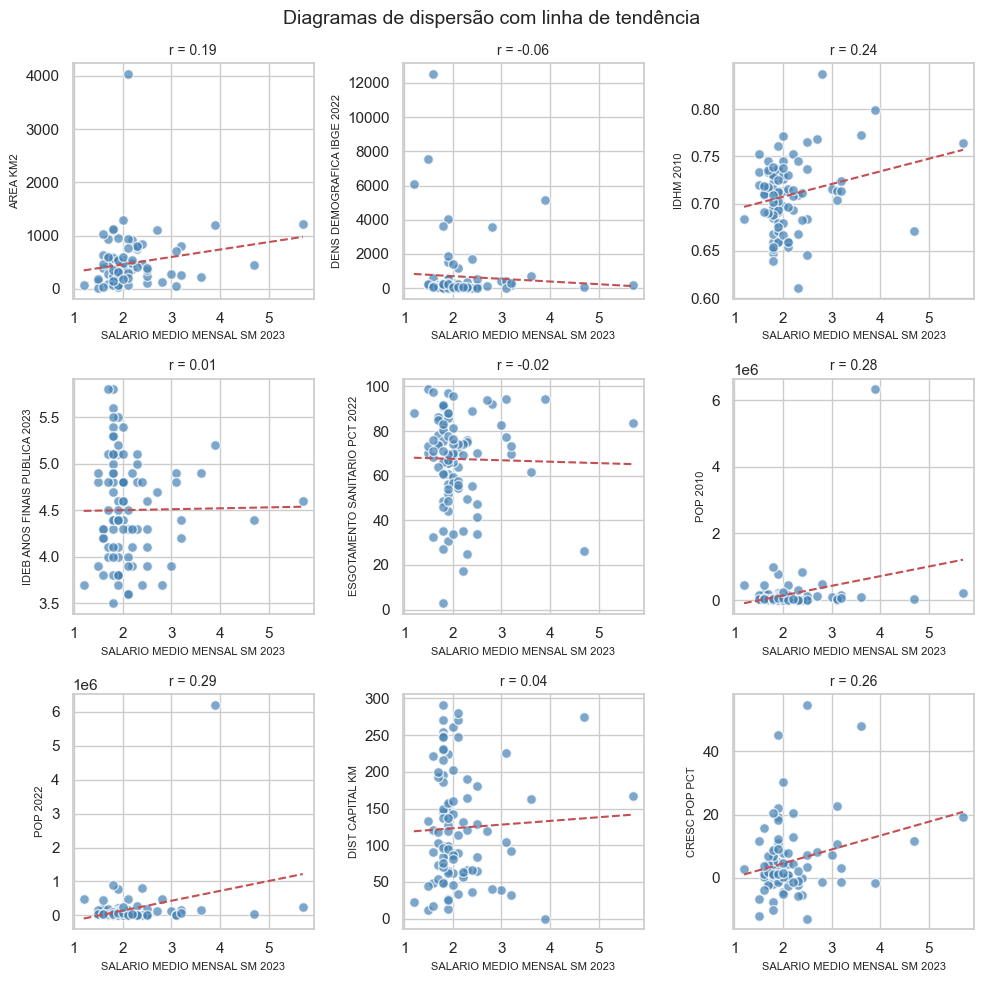

In [156]:
# Scatter plots das variáveis mais correlacionadas com o alvo
# pares = []
# for x in num_cols:
#     for y in num_cols:
#         if x==y: continue
#         pares.append((x,y))

pares =  [('salario_medio_mensal_sm_2023', 'area_km2'),
            ('salario_medio_mensal_sm_2023', 'dens_demografica_ibge_2022'),
            ('salario_medio_mensal_sm_2023', 'idhm_2010'),
            ('salario_medio_mensal_sm_2023', 'ideb_anos_finais_publica_2023'),
            ('salario_medio_mensal_sm_2023', 'esgotamento_sanitario_pct_2022'),
            ('salario_medio_mensal_sm_2023', 'pop_2010'),
            ('salario_medio_mensal_sm_2023', 'pop_2022'),
            ('salario_medio_mensal_sm_2023', 'dist_capital_km'),
            ('salario_medio_mensal_sm_2023', 'cresc_pop_pct')]

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, (x, y) in zip(axes.flat, pares):
    dados = gdf[[x, y]].dropna()
    ax.scatter(dados[x], dados[y], alpha=0.7, edgecolors='white', s=50, color='steelblue')
    # Linha de tendência
    m, b = np.polyfit(dados[x], dados[y], 1)
    xs = np.linspace(dados[x].min(), dados[x].max(), 100)
    ax.plot(xs, m*xs + b, 'r--', linewidth=1.5)
    r = dados[[x,y]].corr().iloc[0,1]
    ax.set_title(f'r = {r:.2f}', fontsize=10)
    ax.set_xlabel(x.upper().replace("_"," "), fontsize=8)
    ax.set_ylabel(y.upper().replace("_"," "), fontsize=8)
    # ax.set_title(col.upper().replace("_"," "), fontsize=9)

plt.suptitle('Diagramas de dispersão com linha de tendência', fontsize=14)
plt.tight_layout()
plt.show()

### **1.2.6 Gráfico de bolhas**

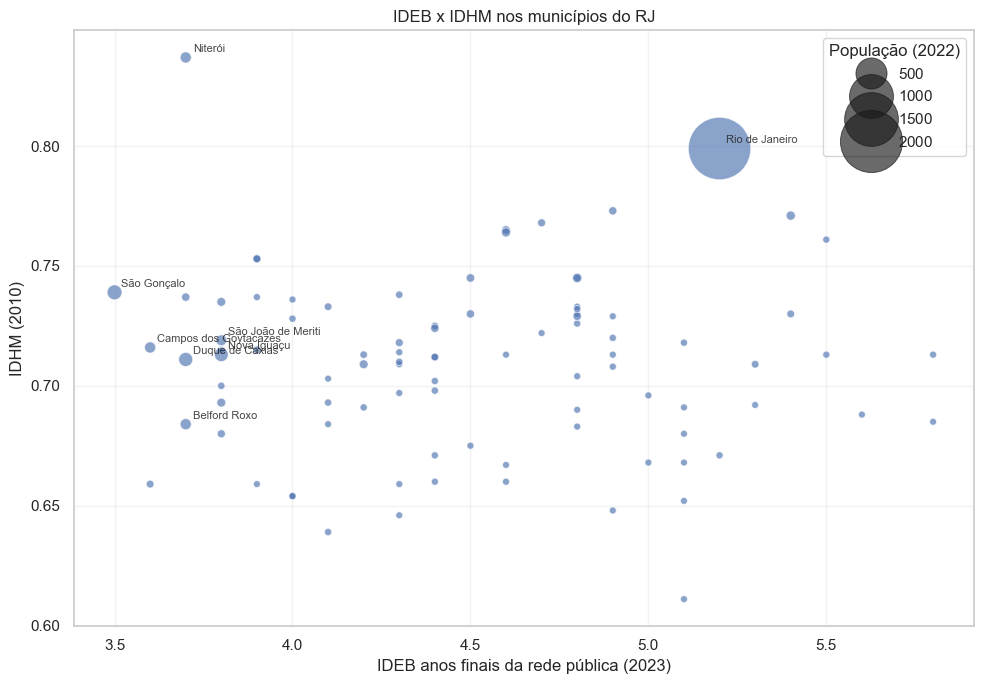

In [214]:
# Gráfico de bolhas: menor para maior bolha
x_col = 'ideb_anos_finais_publica_2023'
y_col = 'idhm_2010'
pop_col = 'pop_2022'

bolhas = (
    gdf[['municipio', x_col, y_col, pop_col]]
    .dropna(subset=[x_col, y_col, pop_col])
    .sort_values(pop_col, ascending=True)
    .copy()
)

# Em matplotlib, s representa área; elevamos o raio ao quadrado para que o raio codifique a população.
raio = np.interp(
    bolhas[pop_col],
    (bolhas[pop_col].min(), bolhas[pop_col].max()),
    (5, 45)
)
bolhas['area_bolha'] = raio ** 2

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    bolhas[x_col],
    bolhas[y_col],
    s=bolhas['area_bolha'],
    # c=bolhas[pop_col],
    # cmap='viridis',
    alpha=0.65,
    edgecolors='white',
    linewidth=0.7
)

for _, row in bolhas.tail(8).iterrows():
    ax.annotate(
        row['municipio'],
        xy=(row[x_col], row[y_col]),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.85
    )

handles, labels = scatter.legend_elements(
    prop='sizes',
    num=4,
)

ax.legend(handles, labels, title='População (2022)', loc='upper right', frameon=True)

# cbar = fig.colorbar(scatter, ax=ax, shrink=0.82)
# cbar.set_label('População (2022)')

ax.set_xlabel('IDEB anos finais da rede pública (2023)')
ax.set_ylabel('IDHM (2010)')
ax.set_title('IDEB x IDHM nos municípios do RJ')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [218]:
handles[0]

### **1.2.6 Clusterização**

<Axes: xlabel='salario_medio_mensal_sm_2023', ylabel='ideb_anos_finais_publica_2023'>

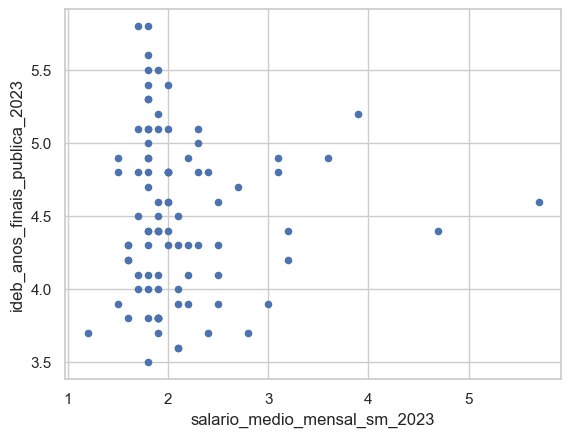

In [179]:
gdf.plot(kind='scatter', x='salario_medio_mensal_sm_2023', y='ideb_anos_finais_publica_2023')

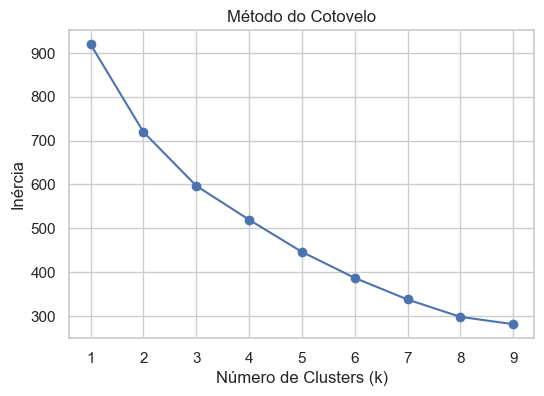

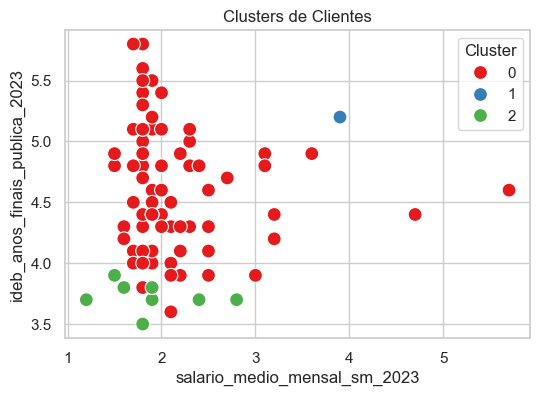

In [180]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. Pré-processamento
# =========================
# Padronizando os dados para evitar que variáveis com escalas diferentes influenciem o modelo
scaler = StandardScaler()
df_scaled = scaler.fit_transform(gdf[num_cols])

# =========================
# 3. Definindo número ideal de clusters (Método do Cotovelo)
# =========================
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.show()

# =========================
# 4. Aplicando K-Means com k=3 (exemplo)
# =========================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
gdf['Cluster'] = kmeans.fit_predict(df_scaled)

# =========================
# 5. Visualização dos clusters
# =========================
plt.figure(figsize=(6, 4))
sns.scatterplot(data=gdf, x='salario_medio_mensal_sm_2023', y='ideb_anos_finais_publica_2023', hue='Cluster', palette='Set1', s=100)
plt.title("Clusters de Clientes")
plt.show()



### 2. Realizar análise exploratória em dados geoespaciais

Em dados geoespaciais, a EDA deve incluir **visualização cartográfica** e a investigação de **autocorrelação espacial** — a tendência de valores semelhantes se agruparem geograficamente.

#### **2.1 Mapas coropléticos**

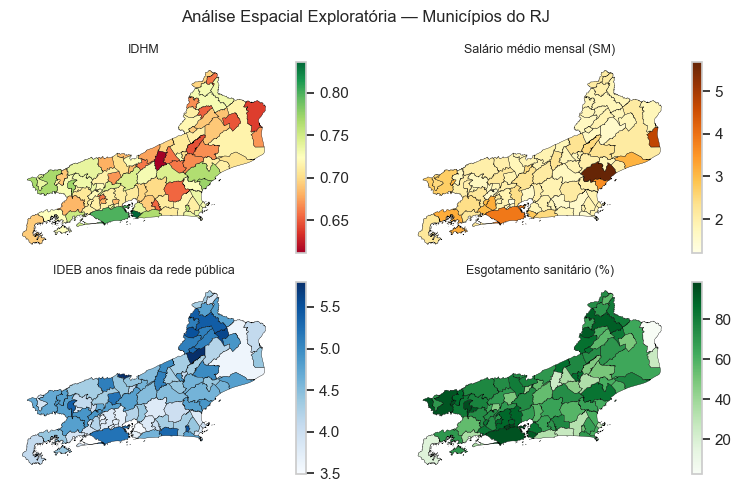

In [ ]:
variaveis = [
    ('idhm_2010',                     'IDHM',                         'RdYlGn'),
    ('salario_medio_mensal_sm_2023',  'Salário médio mensal (SM)',     'YlOrBr'),
    ('ideb_anos_finais_publica_2023', 'IDEB anos finais da rede pública',    'Blues'),
    ('esgotamento_sanitario_pct_2022','Esgotamento sanitário (%)',     'Greens'),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for ax, (col, titulo, cmap) in zip(axes.flatten(), variaveis):
    gdf.plot(column=col, ax=ax, legend=True, cmap=cmap,
             edgecolor='black', linewidth=0.25)
    ax.set_title(titulo, fontsize=9)
    ax.set_axis_off()

plt.suptitle('Análise Espacial Exploratória — Municípios do RJ', fontsize=12)
plt.tight_layout()
plt.show()

#### AutocorrelaÃ§Ã£o Espacial â€” Ãndice de Moran

O **Índice de Moran ($I$)** mede se valores semelhantes tendem a se agrupar no espaço:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

| Valor de $I$ | Interpretação |
|-------------|---------------|
| $I > 0$ | Autocorrelação positiva (valores similares agrupados) |
| $I \approx 0$ | Distribuição aleatória |
| $I < 0$ | Autocorrelação negativa (valores distintos vizinhos) |

In [158]:
# â”€â”€ Ãndice de Moran Global (implementaÃ§Ã£o manual) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from scipy.spatial.distance import cdist

def moran_global(valores, coords, k=4):
    """
    Calcula o índice de Moran usando matriz de pesos KNN (k vizinhos mais próximos).
    coords: array (n, 2) com [lat, lon]
    """
    mascara = ~pd.isna(valores)
    x = np.array(valores, dtype=float)[mascara]
    coords_validos = np.array(coords, dtype=float)[mascara]
    n = len(x)
    xm = x - x.mean()

    # Distâncias entre todos os pares
    D = cdist(coords_validos, coords_validos)
    np.fill_diagonal(D, np.inf)

    # Matriz de pesos binária KNN
    W = np.zeros((n, n))
    for i in range(n):
        vizinhos = np.argsort(D[i])[:k]
        W[i, vizinhos] = 1
    W = (W + W.T)  # Simetrizar
    W = W / W.sum()  # Normalizar

    num = n * np.sum(W * np.outer(xm, xm))
    den = W.sum() * np.sum(xm**2)
    return num / den

coords = df[['lat','lon']].values
for col in ['idhm', 'salario_medio_mensal_sm', 'esgotamento_sanitario_pct']:
    I = moran_global(df[col].values, coords)
    interpretacao = 'agrupamento espacial' if I > 0.1 else ('dispersão' if I < -0.1 else 'aleatório')
    print(f"Moran's I ({col:25s}): {I:+.3f}  →  {interpretacao}")

Moran's I (idhm                     ): +0.171  →  agrupamento espacial
Moran's I (salario_medio_mensal_sm  ): +0.101  →  agrupamento espacial
Moran's I (esgotamento_sanitario_pct): +0.265  →  agrupamento espacial


### 1.4 Engenharia de Features Geoespaciais

Frequentemente, as features mais informativas **não estão no dado original**, mas são derivadas da geometria ou da relação espacial entre feições.

| Feature derivada | Como calcular | Exemplo de uso |
|-----------------|---------------|----------------|
| Distância a uma feição | `geometry.distance()` | Distância à capital, ao mar, a rodovias |
| Densidade de vizinhança | Contagem em buffer | Nº de equipamentos no raio de 5 km |
| Lag espacial | Média dos vizinhos | IDH médio dos municípios vizinhos |
| Área e perímetro | `geometry.area`, `.length` | Compacidade territorial |
| Centroide | `geometry.centroid` | Coordenadas do centro geométrico |

In [159]:
# ── Feature: lag espacial do IDHM (média dos 3 vizinhos mais próximos) ──
from scipy.spatial import cKDTree

tree = cKDTree(coords)
k = 3
dists, idxs = tree.query(coords, k=k+1)  # k+1 porque o próprio ponto é retornado
vizinhos_idx = idxs[:, 1:]               # Exclui o próprio ponto

df['idhm_lag'] = df['idhm'].values[vizinhos_idx].mean(axis=1).round(3)
df['salario_lag'] = df['salario_medio_mensal_sm'].values[vizinhos_idx].mean(axis=1).round(2)
gdf_analise['idhm_lag'] = df['idhm_lag']
gdf_analise['salario_lag'] = df['salario_lag']

print("Features derivadas:")
print(df[['municipio','idhm','idhm_lag','salario_medio_mensal_sm','salario_lag','dens_demografica']].to_string(index=False))

Features derivadas:
                    municipio  idhm  idhm_lag  salario_medio_mensal_sm  salario_lag  dens_demografica
               Angra dos Reis 0.724     0.710                      3.2         2.27             205.8
                      Aperibé 0.692     0.692                      1.8         1.97             116.7
                     Araruama 0.718     0.735                      1.6         1.77             203.2
                        Areal 0.684     0.724                      2.5         2.00             106.8
           Armação dos Búzios 0.728     0.727                      1.9         1.77             563.6
              Arraial do Cabo 0.733     0.730                      1.5         1.80             203.7
               Barra do Piraí 0.733     0.741                      1.7         1.83             158.9
                  Barra Mansa 0.729     0.725                      2.0         2.27             310.5
                 Belford Roxo 0.684     0.736                 

## 2. Selecionar modelos mais adequados à solução

### 2.1 Mapa mental: qual algoritmo usar?

A escolha do modelo depende fundamentalmente da **natureza do problema** e da **variável-alvo**:

```
                        â”Œâ”€â”€â”€ Tenho rÃ³tulos? â”€â”€â”€â”
                       Sim                     Não
                        │                       │
             â”Œâ”€â”€â”€ Aprendizado â”€â”€â”€â”      Aprendizado NÃ£o
             │    Supervisionado │       Supervisionado
             │                  │             │
        Alvo contínuo    Alvo categórico  Agrupamento
             │                  │             │
        Regressão        Classificação   Clusterização
      (Linear, RF,       (RF, SVM,       (K-Means,
       XGBoost...)        KNN...)         DBSCAN...)
```

### 2.2 Considerações espaciais na seleção de modelos

Dados geoespaciais violam frequentemente a **premissa de independência** dos modelos clássicos. Dois problemas principais:

| Problema | Descrição | Solução |
|----------|-----------|--------|
| **Autocorrelação espacial** | Resíduos correlacionados no espaço | Modelos espaciais, features de lag |
| **MAUP** (Problema da Unidade de Área Modificável) | Resultado muda com a escala/agregação | Testar múltiplas escalas |

> **Regra prática:** após qualquer modelo, plote os **resíduos no mapa**. Se houver padrão espacial visível, o modelo ainda não capturou toda a estrutura dos dados.

---

### 2.3 Clusterização espacial — K-Means e DBSCAN

**Problema:** agrupar municípios com perfis socioeconômicos e espaciais similares (aprendizado **não supervisionado**).

#### K-Means
Minimiza a variância intra-cluster. Requer que o número de clusters $k$ seja definido a priori. Usa o **Método do Cotovelo** para escolher $k$.

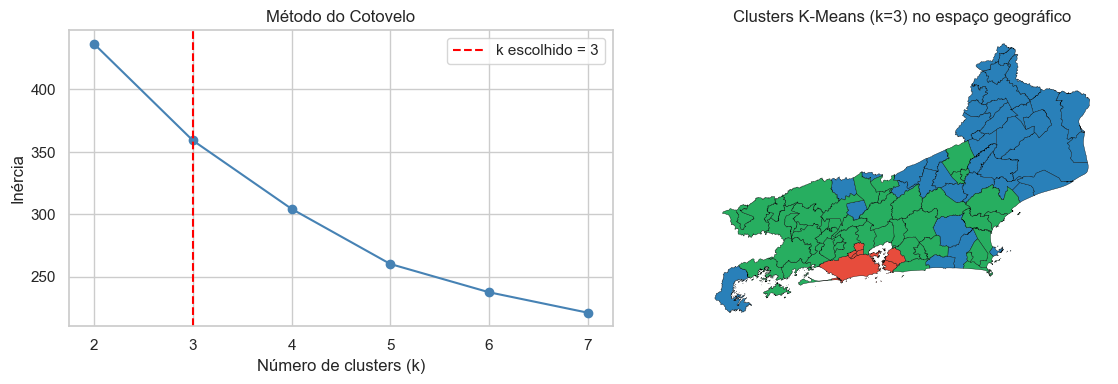


Perfil médio por cluster:
                idhm  salario_medio_mensal_sm  dens_demografica  \
cluster_kmeans                                                    
0               0.75                     2.10           6093.66   
1               0.69                     2.02             75.37   
2               0.72                     2.20            366.54   

                ideb_anos_finais_publica  esgotamento_sanitario_pct  \
cluster_kmeans                                                        
0                                   3.93                      92.97   
1                                   4.75                      57.65   
2                                   4.39                      71.65   

                dist_capital_km  
cluster_kmeans                   
0                         22.00  
1                        187.46  
2                         87.07  


In [160]:
# ── Features para clusterização ────────────────────────────────
feat_cluster = ['idhm','salario_medio_mensal_sm','dens_demografica',
                'ideb_anos_finais_publica','esgotamento_sanitario_pct','dist_capital_km']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feat_cluster])

# ── Método do Cotovelo ─────────────────────────────────────────
inercias = []
Ks = range(2, 8)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cotovelo
axes[0].plot(Ks, inercias, 'o-', color='steelblue')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo')
axes[0].axvline(3, color='red', linestyle='--', label='k escolhido = 3')
axes[0].legend()

# Mapa dos clusters
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = km_final.fit_predict(X_scaled)
gdf_analise['cluster_kmeans'] = df['cluster_kmeans']

cores_cluster = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
for c, cor in cores_cluster.items():
    subset = gdf_analise[gdf_analise['cluster_kmeans'] == c]
    subset.plot(ax=axes[1], color=cor, edgecolor='black', linewidth=0.25)
axes[1].set_title('Clusters K-Means (k=3) no espaço geográfico')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Perfil de cada cluster
print("\nPerfil médio por cluster:")
print(df.groupby('cluster_kmeans')[feat_cluster].mean().round(2))

#### DBSCAN — Clusterização baseada em densidade

Diferente do K-Means, o **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*):
- **Não requer** $k$ definido a priori
- Detecta clusters de **forma arbitrária**
- Identifica **ruído/outliers** (rótulo `-1`)
- Especialmente adequado para **dados espaciais**

Parâmetros principais:
- `eps`: raio da vizinhança
- `min_samples`: mínimo de pontos para formar um núcleo

In [ ]:
# ── DBSCAN sobre coordenadas geográficas (em graus) ───────────
# eps=1.5 graus ≈ ~165 km; min_samples=2
X_geo = df[['lat','lon']].values

db = DBSCAN(eps=1.5, min_samples=2)
df['cluster_dbscan'] = db.fit_predict(X_geo)
gdf_analise['cluster_dbscan'] = df['cluster_dbscan']

n_clusters = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido    = (df['cluster_dbscan'] == -1).sum()
print(f"Clusters encontrados: {n_clusters}")
print(f"Pontos de ruído (isolados): {n_ruido}")
print(df[['municipio','cluster_dbscan']].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
rotulos_unicos = sorted(df['cluster_dbscan'].unique())
palette = cm.tab10.colors
for i, rotulo in enumerate(rotulos_unicos):
    cor   = 'gray' if rotulo == -1 else palette[i % len(palette)]
    label = 'Ruído' if rotulo == -1 else f'Cluster {rotulo}'
    gdf_analise[gdf_analise['cluster_dbscan'] == rotulo].plot(
        ax=ax, color=cor, markersize=70, edgecolor='black'
    )
ax.set_title('DBSCAN — Clusterização por proximidade geográfica')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 2.4 Regressão — prever crescimento populacional

**Problema:** prever `cresc_pop_pct` a partir de atributos socioeconômicos e espaciais (aprendizado **supervisionado, alvo contínuo**).

Comparamos dois modelos:
- **Regressão Linear** — simples, interpretável, assume relação linear
- **Random Forest Regressor** — não-linear, robusto a outliers, captura interações

In [ ]:
feat_reg = ['idhm','salario_medio_mensal_sm','dist_capital_km',
            'ideb_anos_finais_publica','idhm_lag','salario_lag','dens_demografica']

X = df[feat_reg].values
y = df['cresc_pop_pct'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelos = {
    'Regressão Linear'  : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
}

print(f"{'Modelo':<22} {'MAE':>8} {'R²':>8}  (conjunto de teste)")
print('-' * 44)
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"{nome:<22} {mae:>8.3f} {r2:>8.3f}")
    resultados[nome] = {'modelo': modelo, 'y_pred': y_pred, 'mae': mae, 'r2': r2}

# ── Importância de features (Random Forest) ─────────────────────
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(rf.feature_importances_, index=feat_reg).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Valores reais vs preditos
for ax, (nome, res) in zip(axes, resultados.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.7, edgecolors='white', s=60, color='steelblue')
    lims = [min(y_test.min(), res['y_pred'].min()), max(y_test.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{nome}\nMAE={res['mae']:.3f}  R²={res['r2']:.3f}", fontsize=9)
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predito')

plt.suptitle('Regressão: real vs predito', fontsize=11)
plt.tight_layout()
plt.show()

# Importância
fig, ax = plt.subplots(figsize=(6, 4))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importância das features (Random Forest)')
ax.set_xlabel('Importância relativa')
plt.tight_layout()
plt.show()

### 2.5 Classificação — identificar classe de desenvolvimento

**Problema:** prever `classe_dev` (Médio / Alto / Muito Alto) com base nos atributos (aprendizado **supervisionado, alvo categórico**).

A **validação cruzada** (*k-fold cross-validation*) é fundamental quando o dataset é pequeno — usa todo o dado para treino e teste de forma rotativa, fornecendo estimativas mais robustas do desempenho real.

In [ ]:
from sklearn.preprocessing import LabelEncoder

feat_clf = ['idhm','salario_medio_mensal_sm','dist_capital_km','dens_demografica','idhm_lag']

le = LabelEncoder()
y_clf = le.fit_transform(df['classe_dev'].astype(str))
X_clf = df[feat_clf].values

clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Validação cruzada (5-fold)
scores = cross_val_score(clf, X_clf, y_clf, cv=5, scoring='accuracy')
print(f"Acurácia por fold: {scores.round(2)}")
print(f"Acurácia média: {scores.mean():.2f} ± {scores.std():.2f}")

# Treino final e matriz de confusão
X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)
clf.fit(X_tr, y_tr)
y_pred_clf = clf.predict(X_te)

print("\nRelatório de classificação:")
print(classification_report(
    y_te, y_pred_clf,
    labels=np.arange(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))

# Matriz de confusão
cm_arr = confusion_matrix(y_te, y_pred_clf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.show()

### 2.6 Diagnóstico espacial dos resíduos

Após qualquer modelo, é boa prática mapear os resíduos. Um **padrão espacial nos resíduos** indica que o modelo não capturou toda a estrutura dos dados — e que variáveis espaciais adicionais podem melhorar o desempenho.

In [ ]:
# ── Resíduos da Regressão Linear sobre todos os dados ────────
modelo_lin = modelos['Regressão Linear']
modelo_lin.fit(X, y)  # Re-treina com todos os dados para plotar
residuos = y - modelo_lin.predict(X)

gdf_analise['residuo'] = residuos

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mapa dos resíduos
gdf_analise.plot(column='residuo', ax=axes[0], legend=True,
         cmap='RdBu', markersize=100, edgecolor='black',
         legend_kwds={'label': 'Resíduo', 'shrink': 0.7})
for _, row in gdf_analise.iterrows():
    axes[0].annotate(row['municipio'][:5],
                     xy=(row['lon'], row['lat']),
                     xytext=(2, 4), textcoords='offset points', fontsize=6)
axes[0].set_title('Mapa de resíduos da Regressão Linear\n(azul = sub, vermelho = superestimado)')
axes[0].set_axis_off()

# Distribuição dos resíduos
axes[1].hist(residuos, bins=8, edgecolor='white', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribuição dos resíduos')
axes[1].set_xlabel('Resíduo')
axes[1].set_ylabel('Frequência')

plt.suptitle('Diagnóstico Espacial dos Resíduos', fontsize=12)
plt.tight_layout()
plt.show()

# Moran dos resíduos
I_res = moran_global(residuos, coords)
print(f"Moran's I dos resíduos: {I_res:+.3f}")
print("→ Se |I| > 0.1, considere adicionar features de lag espacial ou usar um modelo espacial.")

## Complemento

### Guia de seleção de modelos para dados geoespaciais

| Tipo de problema | Algoritmos recomendados | Atenção espacial |
|-----------------|------------------------|------------------|
| Agrupamento por perfil | K-Means, Agglomerative | Verificar coesão espacial dos clusters |
| Agrupamento por proximidade | DBSCAN, HDBSCAN | Converter para CRS métrico antes |
| Regressão espacialmente estacionária | OLS, Random Forest | Mapear resíduos |
| Regressão com não-estacionariedade | GWR (Geographically Weighted Regression) | Coeficientes variam no espaço |
| Classificação territorial | Random Forest, XGBoost | Usar lag espacial como feature |
| Detecção de hotspots | LISA (Local Moran), Getis-Ord Gi* | Análise local, não global |

### Checklist antes de publicar um modelo

- [ ] Dados divididos corretamente (treino / teste)
- [ ] Padronização/normalização aplicada quando necessário
- [ ] Validação cruzada usada para datasets pequenos
- [ ] Resíduos mapeados e analisados
- [ ] Índice de Moran dos resíduos próximo de zero
- [ ] Feature importance analisada
- [ ] Métricas reportadas com desvio-padrão (cross-val)


## Lista de exercícios complementares

**Exercício 1.** Com o dataset desta aula, calcule a correlação de Pearson entre todas as variáveis numéricas e identifique o par com maior e menor correlação. Interprete cada resultado no contexto territorial.

**Exercício 2.** Aplique K-Means com $k \in \{2, 3, 4, 5\}$ usando apenas as coordenadas geográficas (`lat`, `lon`). Compare os mapas resultantes com os clusters obtidos usando variáveis socioeconômicas. Os agrupamentos coincidem? O que isso indica?

**Exercício 3.** Aplique DBSCAN variando `eps` entre 0.5 e 3.0 (passo 0.5). Para cada configuração, registre o número de clusters e de pontos de ruído. Qual configuração você considera mais adequada para o RJ? Justifique.

**Exercício 4.** Treine um `RandomForestRegressor` para prever `cresc_pop_pct` usando apenas variáveis oficiais do IBGE Cidades (`idhm`, `salario_medio_mensal_sm`, `ideb_anos_finais_publica`, `esgotamento_sanitario_pct`). Calcule o MAE e R² por validação cruzada (5-fold). Mapeie os resíduos e calcule o Índice de Moran dos resíduos.

**Exercício 5.** Crie manualmente uma feature de *lag espacial* para a variável `salario_medio_mensal_sm` usando os 5 vizinhos mais próximos. Adicione essa feature ao modelo de regressão e compare o R² antes e depois. A autocorrelação espacial dos resíduos diminuiu?

**Exercício 6 (desafio).** Implemente a **GWR simplificada** (Geographically Weighted Regression): para cada município $i$, treine uma regressão linear ponderada pelos inversos das distâncias aos demais municípios. O alvo é `cresc_pop_pct`. Compare os coeficientes obtidos para `idhm` em municípios da região serrana versus litoral. Os coeficientes são estacionários?